In [27]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Any


In [28]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    summary: str


In [38]:
def calculate_sr(state: BatsmanState):

    sr=(state["runs"] / state["balls"]) * 100
    
    return {'sr':sr}

In [39]:
def calculate_bpb(state: BatsmanState):

    bpb =(state["balls"] / (state['fours']) + state['sixes'])

    return {'bpb':bpb}

In [40]:
def calculate_boundary_percent(state: BatsmanState):

    boundary_percent = (((state['fours']*4)  + (state['sixes']*6)) / state['runs']) * 100


    return {'boundary_percent':boundary_percent}

In [41]:
def summary(state: BatsmanState):

    summary=f"""
    strike rate: {state['sr']:.2f}\n
    Balls per Boundary :{state['bpb']:.2f}\n
    Boundary Percentage: {state['boundary_percent']:.2f}%


    """

    return {'summary':summary}

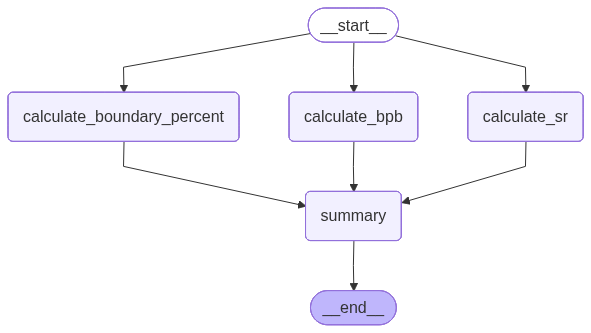

In [42]:
graph = StateGraph(BatsmanState)

graph.add_node('calculate_sr', calculate_sr)
graph.add_node('calculate_bpb', calculate_bpb)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary', summary)

# defining the edges

graph.add_edge(START, 'calculate_sr')
graph.add_edge(START, 'calculate_bpb')
graph.add_edge(START, 'calculate_boundary_percent')

graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpb', 'summary')
graph.add_edge('calculate_boundary_percent', 'summary')

graph.add_edge('summary', END)

graph.compile()



In [43]:
workflow=graph.compile()

In [45]:
initial_state= {
    'runs': 100,
    'balls':50,
    'fours':6,
    'sixes':4
}


workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 12.333333333333334,
 'boundary_percent': 48.0,
 'summary': '\n    strike rate: 200.00\n\n    Balls per Boundary :12.33\n\n    Boundary Percentage: 48.00%\n\n\n    '}